In [14]:
#### GINKO dataset
# !pip install seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up clean plotting styles for Jupyter
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load the file (replace with your exact local path if necessary)
df = pd.read_parquet("../BioXAI_Hackathon/VCPI_data/vcpi_tvc-qnu-012_counts.parquet") #### VCPI_metadata

# Display the first few rows to confirm loading
df.head()

,gene_id,116471544,116471545,116471546,116471547,116471548,116471549,116471550,116471551,116471552,...,116540749,116540750,116540751,116540752,116540753,116540754,116540755,116540756,116540757,116540758
0,ENSG00000290825,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ENSG00000223972,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000310526,1,3,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,1,0
3,ENSG00000227232,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000278267,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.columns

Index(['114546198', '114546199', '114546200', '114546201', '114546202',
       '114546203', '114546204', '114546205', '114546206', '114546207',
       ...
       '114666695', '114666696', '114666697', '114666698', '114666699',
       '114666700', '114666701', '114666702', '114666703', 'gene_id'],
      dtype='object', length=29173)

In [16]:
df.shape

(78778, 21889)

In [24]:
count_matrix = df.set_index('gene_id')

# 2. Transpose so rows = samples (sequenced_id), columns = genes
counts_df = count_matrix.T
counts_df.index.name = 'sequenced_id'

# 3. Convert the index to integer if your metadata 'sequenced_id' is numeric
counts_df.index = counts_df.index.astype(int)

In [25]:
counts_df

gene_id,ENSG00000290825,ENSG00000223972,ENSG00000310526,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000284332,ENSG00000237613,ENSG00000308361,ENSG00000290826,...,ERCC-00157,ERCC-00158,ERCC-00160,ERCC-00162,ERCC-00163,ERCC-00164,ERCC-00165,ERCC-00168,ERCC-00170,ERCC-00171
sequenced_id,,,,,,,,,,,,,,,,,,,,,
116471544,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
116471545,0,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
116471546,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
116471547,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
116471548,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116540754,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
116540755,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
116540756,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
############ Quick QC 
# 1. Filter out lowly expressed genes (optional but highly recommended to speed up ML)
# Keep genes that have at least 10 counts in at least 5% of the samples
min_reads = 10
min_samples = int(0.05 * len(counts_df))
genes_to_keep = (counts_df >= min_reads).sum(axis=0) >= min_samples
counts_filtered = counts_df.loc[:, genes_to_keep]

# 2. Log-normalize using Counts Per Million (CPM) adjustment
# (Dividing by row totals and taking log2 stabilizes variance for trees/neural nets)
row_sums = counts_filtered.sum(axis=1)
counts_normalized = counts_filtered.div(row_sums, axis=0) * 1e6
counts_normalized = np.log2(counts_normalized + 1)

In [29]:
counts_normalized

gene_id,ENSG00000225972,ENSG00000225630,ENSG00000237973,ENSG00000229344,ENSG00000248527,ENSG00000228794,ENSG00000188976,ENSG00000187608,ENSG00000131591,ENSG00000078808,...,ENSG00000228253,ENSG00000198899,ENSG00000198938,ENSG00000198840,ENSG00000212907,ENSG00000198886,ENSG00000198786,ENSG00000198695,ENSG00000198727,ENSG00000210196
sequenced_id,,,,,,,,,,,,,,,,,,,,,
116471544,2.141247,7.054292,9.640494,3.163500,7.313455,2.141247,2.141247,5.502987,2.741083,6.523115,...,8.324349,12.203573,12.993953,11.925567,8.546830,12.782974,8.803358,8.648447,11.362760,9.449575
116471545,3.075435,6.844459,9.321772,2.573605,6.823582,3.075435,2.573605,5.122887,2.760954,6.558889,...,8.642819,11.838113,12.662577,11.769499,8.581964,12.417730,8.588166,8.478919,10.967815,9.327344
116471546,2.621973,7.282416,9.649724,4.501748,6.914292,1.614647,0.000000,4.900776,2.621973,6.401320,...,8.691650,12.149217,13.047462,12.031909,8.744635,12.816402,9.216652,9.209131,11.476304,9.966096
116471547,3.145915,7.296061,9.527799,3.145915,7.080521,3.281526,1.456684,4.668276,2.422750,6.163159,...,7.728716,11.980189,12.940530,11.844402,8.594675,12.481228,8.797803,8.581593,11.069908,9.574766
116471548,1.540790,7.376560,9.711378,3.523870,7.123516,3.523870,1.540790,4.793559,4.328792,6.728255,...,8.250850,12.201779,13.238152,12.078534,8.664703,12.865816,9.026106,8.759922,11.485435,9.803661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116540754,2.572524,6.746750,9.609570,2.572524,6.295105,2.925617,2.925617,5.428349,2.103999,5.283123,...,8.571314,11.177462,12.452541,11.814853,8.561899,11.958403,8.699914,9.035391,10.659556,9.877113
116540755,3.081915,7.045420,9.701077,2.767222,6.627980,1.411110,3.453715,4.908803,2.579723,5.163810,...,9.414031,11.190725,12.373225,11.939278,8.761909,12.017582,8.888541,9.142622,10.705238,9.875596
116540756,2.093984,7.005634,9.765902,3.062781,6.677323,1.787407,2.561663,5.522063,2.561663,5.270395,...,8.740245,11.243373,12.559387,11.975813,8.589229,12.004507,8.916521,9.010968,10.783252,10.079892


In [23]:
###### open one compund file 
compounds_df = pd.read_csv("../BioXAI_Hackathon/VCPI_data/compounds-tvc-qnu-012-2026-05-29.csv") #### VCPI_compound
print("Number of unique compounds are: ", len(compounds_df.user_compound_id.unique()))
compounds_df.head()

Number of unique compounds are:  10261


,compound,user_compound_id,smiles,purity_pct,molecular_weight,log_p,tpsa,inchi_key,num_rotatable_bonds,num_h_acceptors,num_h_donors,num_atoms,num_bonds
0,f1361a6b-37d0-416e-bfa6-b93361c012c2,9320172,Cc1ccc(OS(=O)(=O)c2ccc(Br)cc2)c(C)c1,NaN,341.23,3.83,43.37,MPARORXOSIZXSH-UHFFFAOYSA-N,3,3,0,19,20
1,de53ce80-2f0b-4cd2-8b4a-237c68c82a1d,9321684,CCC(=O)Oc1ccc2c(c1)O/C(=C\c1cc(OC)c(OC)cc1OC)C2=O,NaN,384.38,3.64,80.29,FNRNSKVVSJTLMN-OCKHKDLRSA-N,6,7,0,28,30
2,9315b909-ff93-403b-9405-9c1cd5cca2e1,9320795,Cc1ccc(-c2ccc(/C=C(\C#N)C(=O)N3CCOCC3)o2)cc1,NaN,322.36,3.02,66.47,AVEASCCTZPJEJN-FOWTUZBSSA-N,3,4,0,24,26
3,10d1cd96-e373-4b88-8ff9-ba8ff1df7279,9314369,O=C(NC1CCCCC1)N1CCN(c2ccc3nncn3n2)CC1,NaN,329.41,1.29,78.66,RWEHHTOXSZVZBK-UHFFFAOYSA-N,2,6,1,24,27
4,476af0b6-0664-4e45-89a0-68bbf9494625,9318337,CC(=O)c1ccc(Oc2ncnc(N)c2[N+](=O)[O-])cc1,NaN,274.24,1.96,121.24,RKYJPLWVYRPNHW-UHFFFAOYSA-N,4,7,1,20,21


In [22]:
compounds_df.columns

Index(['compound', 'user_compound_id', 'smiles', 'purity_pct',
       'molecular_weight', 'log_p', 'tpsa', 'inchi_key', 'num_rotatable_bonds',
       'num_h_acceptors', 'num_h_donors', 'num_atoms', 'num_bonds'],
      dtype='object')

In [31]:
#### open a metadata file 
metadata_df = pd.read_csv("../BioXAI_Hackathon/VCPI_data/metadata-tvc-qnu-012.csv") #### VCPI_metadata
metadata_df.head(2)

,sequenced_id,job_id,container_id,column_id,row_id,is_edge,compound,user_compound_id,compound_concentration,compound_concentration_unit,...,total_sequenced_reads,total_umi_count,ngenes3,n_mapped,percent_mapped,percent_rrna_removed,percent_mitochondrial,unassigned_multimapping,unassigned_nofeatures,percent_duplicated
0,116471544,tvc-qnu-012,1839025,1,1,True,e24cec84-a4a0-42b4-8914-67d02876a890,DMSO,0.15,%,...,2301152,888404,10858,1770243,86.07,10.63,5.215195,349502,109315,0.649494
1,116471545,tvc-qnu-012,1839025,1,2,True,9815b4fc-f243-497b-b5a1-408d0ac26e60,1306737,10000.00,nM,...,3087310,1222144,11371,2442721,86.80,8.85,4.305712,464527,122958,0.635829


In [21]:
metadata_df.columns

Index(['sequenced_id', 'job_id', 'container_id', 'column_id', 'row_id',
       'is_edge', 'compound', 'user_compound_id', 'compound_concentration',
       'compound_concentration_unit', 'cell_line', 'timepoint', 'condition',
       'percent_volume_dmso', 'is_control', 'seeded_cell_count',
       'total_sequenced_reads', 'total_umi_count', 'ngenes3', 'n_mapped',
       'percent_mapped', 'percent_rrna_removed', 'percent_mitochondrial',
       'unassigned_multimapping', 'unassigned_nofeatures',
       'percent_duplicated'],
      dtype='object')

In [56]:
metadata_df['percent_mitochondrial']

0        5.215195
1        4.305712
2        5.450177
3        4.580870
4        5.702696
           ...   
21883    3.764127
21884    3.861863
21885    4.006019
21886    4.017984
21887    3.906649
Name: percent_mitochondrial, Length: 21888, dtype: float64

In [30]:
# 1. Merge metadata with compound features
# We select the columns we need from compounds to prevent column clashing
compounds_subset = compounds_df[['compound', 'smiles', 'molecular_weight', 'log_p', 
                                 'tpsa', 'num_rotatable_bonds', 'num_h_acceptors', 
                                 'num_h_donors', 'num_atoms', 'num_bonds']]

meta_compounds = pd.merge(metadata_df, compounds_subset, on='compound', how='inner')

# 2. Merge the resulting df with your normalized counts matrix
master_df = pd.merge(meta_compounds, counts_normalized, on='sequenced_id', how='inner')

print(f"Master DataFrame shape: {master_df.shape}")

Master DataFrame shape: (21888, 10352)


In [43]:
master_df.head(5)

,sequenced_id,job_id,container_id,column_id,row_id,is_edge,compound,user_compound_id,compound_concentration,compound_concentration_unit,...,ENSG00000228253,ENSG00000198899,ENSG00000198938,ENSG00000198840,ENSG00000212907,ENSG00000198886,ENSG00000198786,ENSG00000198695,ENSG00000198727,ENSG00000210196
0,116471544,tvc-qnu-012,1839025,1,1,True,e24cec84-a4a0-42b4-8914-67d02876a890,DMSO,0.15,%,...,8.324349,12.203573,12.993953,11.925567,8.546830,12.782974,8.803358,8.648447,11.362760,9.449575
1,116471545,tvc-qnu-012,1839025,1,2,True,9815b4fc-f243-497b-b5a1-408d0ac26e60,1306737,10000.00,nM,...,8.642819,11.838113,12.662577,11.769499,8.581964,12.417730,8.588166,8.478919,10.967815,9.327344
2,116471546,tvc-qnu-012,1839025,1,3,True,1c40fdc5-e3ce-44b5-8a7d-8b4b004e9f3f,8632751,10000.00,nM,...,8.691650,12.149217,13.047462,12.031909,8.744635,12.816402,9.216652,9.209131,11.476304,9.966096
3,116471547,tvc-qnu-012,1839025,1,4,True,6c31658c-525c-4022-b807-470bc01963a0,8633329,10000.00,nM,...,7.728716,11.980189,12.940530,11.844402,8.594675,12.481228,8.797803,8.581593,11.069908,9.574766
4,116471548,tvc-qnu-012,1839025,1,5,True,fb836044-82c5-4326-8afa-0ddbbe57738e,8633680,10000.00,nM,...,8.250850,12.201779,13.238152,12.078534,8.664703,12.865816,9.026106,8.759922,11.485435,9.803661


In [41]:
######## Generate features based on SMILES #####
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

# 1. Initialize the Morgan Generator once (outside your functions to save memory)
# radius=2 corresponds to the classic ECFP4 fingerprint
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def smiles_to_fingerprint_clean(smiles):
    try:
        # Check if the SMILES string is valid/readable
        if pd.isna(smiles) or not isinstance(smiles, str):
            return [0] * 1024
            
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # 2. Generate the fingerprint using the new object syntax
            fp = morgan_gen.GetFingerprint(mol)
            return list(fp)
    except Exception as e:
        pass
    
    # Return a vector of zeros if structural parsing fails
    return [0] * 1024

# Extract unique smiles to save compute time, map them, and build an array
unique_smiles = master_df['smiles'].drop_duplicates().to_frame()
unique_smiles['fp'] = unique_smiles['smiles'].apply(smiles_to_fingerprint)

# Convert list columns to a separate DataFrame of features
fp_features = pd.DataFrame(unique_smiles['fp'].tolist(), index=unique_smiles['smiles'])

[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerator
[11:49:33] DEPRECATION WARNING: please use MorganGenerat

In [42]:
fp_features

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
smiles,,,,,,,,,,,,,,,,,,,,,
CS(C)=O,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nc1ncnc2c1ncn2[C@@H]1O[C@@H]2COP(=O)(O)O[C@H]2[C@H]1O,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
N=c1nc(OCc2ccccc2)c2nc[nH]c2[nH]1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
C[C@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C@@]3(F)[C@@H](O)C[C@]2(C)[C@@]1(O)C(=O)CO,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
Cl.N=c1ccn([C@@H]2O[C@H](CO)[C@@H](O)[C@@H]2O)c(O)n1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
COc1ccccc1-c1c(C)oc2cc(OC(=O)c3ccco3)ccc2c1=O,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CNC1CCC(=O)NC1=O,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
COC(=O)COc1ccc2oc(=O)c(-c3cc(OC)ccc3OC)c(C)c2c1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
######## identify some genes which have differential expression across compounds
######## so that ML model can train from it 

# 1. Calculate the variance for each gene (columns)
gene_variances = counts_normalized.var(axis=0)

# 2. Sort the genes by variance in descending order
sorted_genes = gene_variances.sort_values(ascending=False)

# 3. View the top 10 most variable genes
print("Top 10 Highly Variable Genes in your dataset:")
print(sorted_genes.head(10))

# 4. Automatically pick the #1 top variable gene as your target 'y'
top_variable_gene = sorted_genes.index[0]
print(f"\nRecommended target gene (y): {top_variable_gene}")

# Extract it for your model
y = counts_normalized[top_variable_gene]

Top 10 Highly Variable Genes in your dataset:
gene_id
ENSG00000276070    2.019268
ENSG00000275302    1.885988
ENSG00000214026    1.366876
ENSG00000276085    1.256132
ENSG00000146674    1.241500
ENSG00000125538    1.176541
ENSG00000170323    1.170354
ENSG00000182676    1.107791
ENSG00000115165    1.083814
ENSG00000171051    1.065005
dtype: float64

Recommended target gene (y): ENSG00000276070


In [47]:
############# Align fingerprint features with the target expression data (master dataframe) ######

# 1. Assuming fp_features has 'smiles' as its index
# Reset index to easily merge it back
fp_features_df = fp_features.reset_index().rename(columns={'index': 'smiles'})

# 2. Merge the fingerprint features back into your master data frame
final_ml_df = pd.merge(master_df, fp_features_df, on='smiles', how='inner')

# 3. Separate your chemical features (X) from your biological targets (y)
# Let's extract the fingerprint column names (usually integers 0 to 1023)
fp_cols = [col for col in fp_features.columns if col != 'smiles']

# Include physical properties alongside fingerprints for a stronger feature set
property_cols = ['molecular_weight', 'log_p', 'tpsa', 'num_rotatable_bonds', 'num_h_acceptors', 'num_h_donors']
feature_cols = property_cols + fp_cols

X = final_ml_df[feature_cols]

# For the target (y), choose a highly variable or key oncogene/marker from your normalized counts
# Example: let's pick a representative gene like 'TP53' or your top variable gene
target_gene = 'ENSG00000276070'  # Change this to an actual gene_id present in your columns
y = final_ml_df[target_gene]

In [48]:
y

0        1.095684
1        0.000000
2        1.022320
3        0.000000
4        0.966998
           ...   
21883    0.000000
21884    0.871614
21885    0.000000
21886    3.400432
21887    0.000000
Name: ENSG00000276070, Length: 21888, dtype: float64

In [49]:
##### Set a train-test split

from sklearn.model_selection import train_test_split

# A standard random split for a quick validation baseline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shapes: {X_train.shape}, Test shapes: {X_test.shape}")

Training shapes: (17510, 1030), Test shapes: (4378, 1030)


In [52]:
#!pip install xgboost
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Initialize an XGBoost Regressor to predict continuous normalized log-counts
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)

# Evaluate performance
preds = model.predict(X_test)
print(f"Test R² Score: {r2_score(y_test, preds):.3f}")
print(f"Test MSE: {mean_squared_error(y_test, preds):.3f}")

Test R² Score: 0.385
Test MSE: 1.229


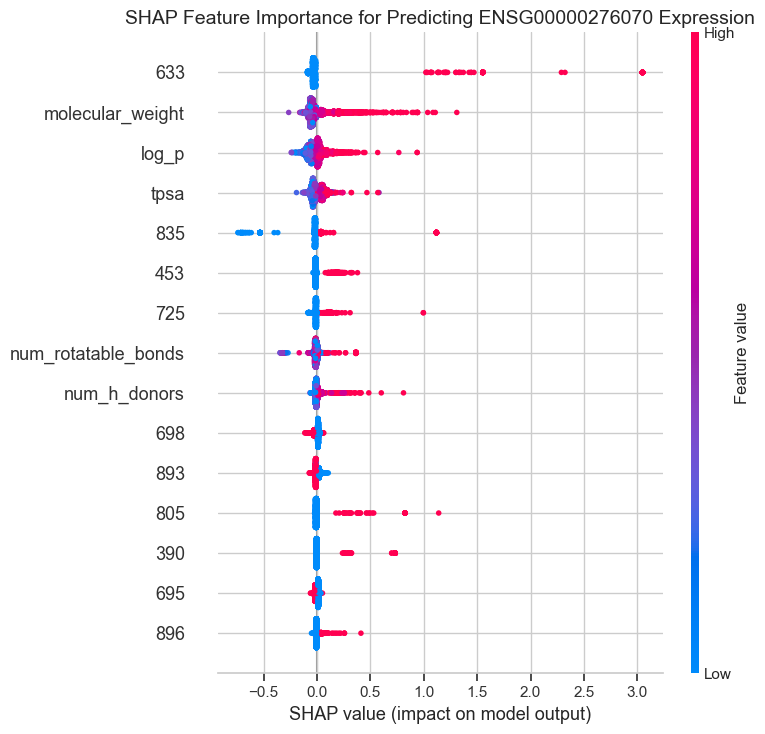

In [55]:
##### SHAP explainability
# !pip install shap
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Tree Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# 2. Plot the Summary Plot
# This displays the top features driving your gene predictions
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title(f"SHAP Feature Importance for Predicting {target_gene} Expression", fontsize=14)
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `ngenes3` for `x`. An entry with this name does not appear in `data`.

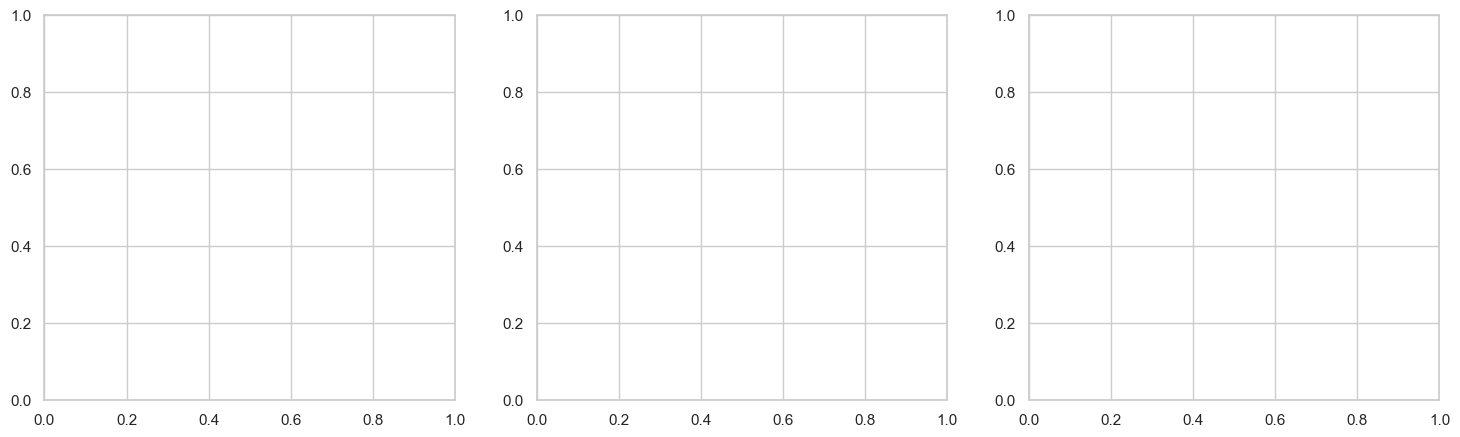

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of unique genes detected
sns.histplot(data=df, x="ngenes3", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Unique Genes Detected")
axes[0].set_xlabel("Number of Genes (ngenes3)")

# 2. Distribution of total UMI counts (transcript abundance)
sns.histplot(data=df, x="total_umi_count", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribution of Total UMI Counts")
axes[1].set_xlabel("Total UMIs")

# 3. Distribution of Mitochondrial read percentage (Cell stress/viability)
sns.histplot(data=df, x="percent_mitochondrial", kde=True, ax=axes[2], color="lightgreen")
axes[2].set_title("Distribution of Mitochondrial Read %")
axes[2].set_xlabel("Mitochondrial %")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

# Boxplot comparing how different sample types alter the total number of genes expressed
sns.boxplot(
    data=df, 
    x="sample_type", 
    y="ngenes3", 
    hue="sample_type", 
    palette="Set2", 
    legend=False
)

plt.title("Impact of Sample Type on Total Expressed Genes", fontsize=14, pad=15)
plt.xlabel("Sample Type", fontsize=12)
plt.ylabel("Number of Genes Detected (ngenes3)", fontsize=12)
plt.xticks(rotation=15)

plt.show()

In [ ]:
# Scatter plot tracking complexity vs. sequencing depth, colored by control status
sns.scatterplot(
    data=df, 
    x="total_sequenced_reads", 
    y="ngenes3", 
    hue="is_neg_control", 
    alpha=0.8, 
    palette={True: "gray", False: "crimson"}
)

plt.title("Sequencing Depth vs. Number of Unique Genes Detected", fontsize=14)
plt.xlabel("Total Sequenced Reads", fontsize=12)
plt.ylabel("Unique Genes (ngenes3)", fontsize=12)
plt.legend(title="Is DMSO Control?")

plt.show()

In [ ]:
# Select key numeric QC metrics
qc_columns = [
    "total_sequenced_reads", "total_umi_count", "sequencing_saturation", 
    "ngenes3", "n_mapped", "percent_mapped", "percent_mitochondrial"
]

# Compute correlation matrix
corr_matrix = df[qc_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Transcriptomic QC Metrics", fontsize=14, pad=15)

plt.show()

In [ ]:
compounds = df[~df['sample_type'].str.contains('Control', na=False)]['compound'].unique().tolist()

print(f"Found {len(compounds)} unique active compounds to look up.")

In [ ]:
compounds

In [ ]:
import time
def get_smiles_from_chembl(compound_name):
    """Queries ChEMBL API by molecule name and extracts canonical SMILES."""
    url = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json"
    params = {
        'pref_name__iexact': compound_name,  # Case-insensitive name match
        'format': 'json'
    }
    
    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            # Check if any matching molecules were found
            if data.get('molecules'):
                # Extract canonical SMILES from the first record's structure sub-dictionary
                structures = data['molecules'][0].get('molecule_structures', {})
                if structures:
                    return structures.get('canonical_smiles', None)
        return None
    except Exception as e:
        return None

# Dictionary to hold our mapping results
smiles_mapping = {}

print("Starting ChEMBL structural lookup...")
for i, comp in enumerate(compounds):
    smiles = get_smiles_from_chembl(comp)
    smiles_mapping[comp] = smiles
    
    # Progress check
    if (i + 1) % 10 == 0 or (i + 1) == len(compounds):
        print(f"Processed {i + 1}/{len(compounds)} compounds...")
        
    # Politeness delay to prevent getting rate-limited by ChEMBL
    time.sleep(0.2)

print("Lookup complete!")

In [ ]:
get_smiles_from_chembl(comp)

In [ ]:
comp

In [ ]:
compounds

In [ ]:
###### look into gene_counts parquet
# !pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Load the count matrix
counts_df = pd.read_parquet("../gene_counts-2.parquet")

# If 'gene_symbol' or 'gene_id' is a column, set it as the index
if 'gene_id' in counts_df.columns:
    counts_df = counts_df.set_index('gene_id')
elif 'gene_symbol' in counts_df.columns:
    counts_df = counts_df.set_index('gene_symbol')

print(f"Matrix Shape: {counts_df.shape[0]} genes across {counts_df.shape[1]} samples.")

# Calculate sparsity (percentage of zeros in the dataset)
zero_percentage = (counts_df == 0).sum().sum() / counts_df.size * 100
print(f"Dataset Sparsity: {zero_percentage:.2f}% of the matrix is zeros.")

In [ ]:
counts_df

In [ ]:
import requests

def get_smiles_from_chembl_robust(compound_name):
    """Robust query targeting both primary preferred names and sub-nested synonyms."""
    base_url = "https://www.ebi.ac.uk/chembl/api/data/molecule.json"
    
    # Tier 1: Search by Primary Preferred Name
    try:
        response = requests.get(base_url, params={'pref_name__iexact': compound_name, 'format': 'json'}, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data.get('molecules'):
                structures = data['molecules'][0].get('molecule_structures', {})
                if structures and structures.get('canonical_smiles'):
                    return structures['canonical_smiles']
    except Exception:
        pass # Fall through to Tier 2 if network hiccups occur
        
    # Tier 2: Deep search through nested synonyms array if Tier 1 is blank
    try:
        response = requests.get(base_url, params={'molecule_synonyms__molecule_synonym__iexact': compound_name, 'format': 'json'}, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data.get('molecules'):
                structures = data['molecules'][0].get('molecule_structures', {})
                if structures and structures.get('canonical_smiles'):
                    return structures['canonical_smiles']
    except Exception:
        return None
        
    return None

smiles_mapping = {}

print("Starting ChEMBL structural lookup...")
for i, comp in enumerate(compounds):
    smiles = get_smiles_from_chembl(comp)
    smiles_mapping[comp] = smiles
    
    # Progress check
    if (i + 1) % 10 == 0 or (i + 1) == len(compounds):
        print(f"Processed {i + 1}/{len(compounds)} compounds...")
        
    # Politeness delay to prevent getting rate-limited by ChEMBL
    time.sleep(0.2)

print("Lookup complete!")

In [ ]:
smiles_mapping

smiles_lookup_df = pd.DataFrame.from_dict(smiles_mapping, orient='index', columns=['smiles'])

print(smiles_lookup_df)

smiles_lookup_df.to_csv('../BioXAI_Hackathon/all_mapping_smiles_for_active_compunds.csv', index = True)

In [ ]:
smiles_mapping

In [ ]:
###### make morgan footprints for smiles ####
#### 1. traditional approach: calculate morgan footprint
#### 2. ChemBerta Model: obtain embeddings
compunds_smiles = pd.read_csv('../BioXAI_Hackathon/all_mapping_smiles_for_active_compunds.csv')
compunds_smiles[compunds_smiles['smiles'].notna()]

In [ ]:
df.columns